In [1]:
from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.data.schema import EmbodimentTag
from gr00t.experiment.data_config import load_data_config

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2025-10-10 20:48:02.400806: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-10 20:48:02.538088: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-10 20:48:02.538130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register fac

In [2]:
DATA_CONFIG_CLS = "examples.UAV_Flow.custom_data_config:UAVFlowFirstLastFrameStateDataConfig"
DATASET_PATH = "/home/shrelic/projects/UAV-Flow-Gr00t/UAVFlowLeRobot-train"

data_config_cls = load_data_config(DATA_CONFIG_CLS)
modality_configs = data_config_cls.modality_config()

Loading external config: examples.UAV_Flow.custom_data_config.UAVFlowFirstLastFrameStateDataConfig


In [3]:
dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_configs,
    embodiment_tag=EmbodimentTag.NEW_EMBODIMENT,
    video_backend="torchvision_av",
)

Initialized dataset UAVFlowLeRobot-train with EmbodimentTag.NEW_EMBODIMENT


In [4]:
dataset[0].keys()

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


dict_keys(['video.ego_view', 'state.drone', 'action.delta_pose', 'annotation.human.action.task_description'])

In [5]:
dataset[0]["video.ego_view"].shape, dataset[0]["state.drone"].shape

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


((2, 256, 256, 3), (1, 4))

In [6]:
dataset[2]["state.drone"]

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


array([[-0.09009264,  0.06201779,  0.        , -0.18875885]])

/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/home/shrelic/miniforge3/envs/gr00t/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


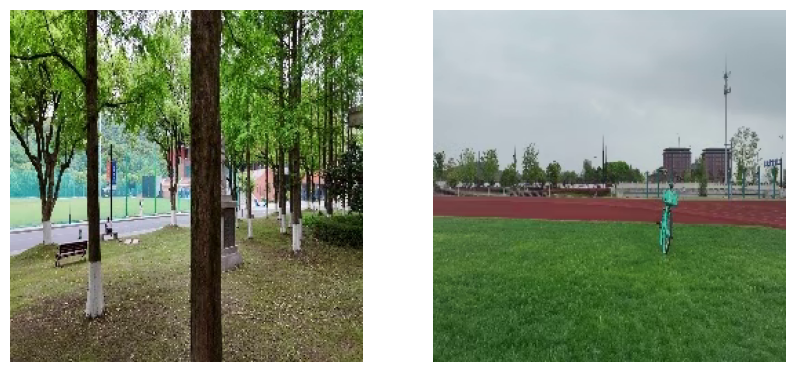

In [17]:
# %matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

indices = [50, 209]

fig, axs = plt.subplots(1, len(indices), figsize=(10, 10))
for i, idx in enumerate(indices):
    frame1 = dataset[idx]["video.ego_view"][0] # frame: HWC
    if len(indices) == 1:
        axs = [axs]
    axs[i].imshow(frame1)
    axs[i].axis("off")
plt.show()

AssertionError: Parquet file not found at /home/shrelic/projects/UAV-Flow-Gr00t/UAVFlowLeRobot-train/data/chunk-000/episode_000000.parquet

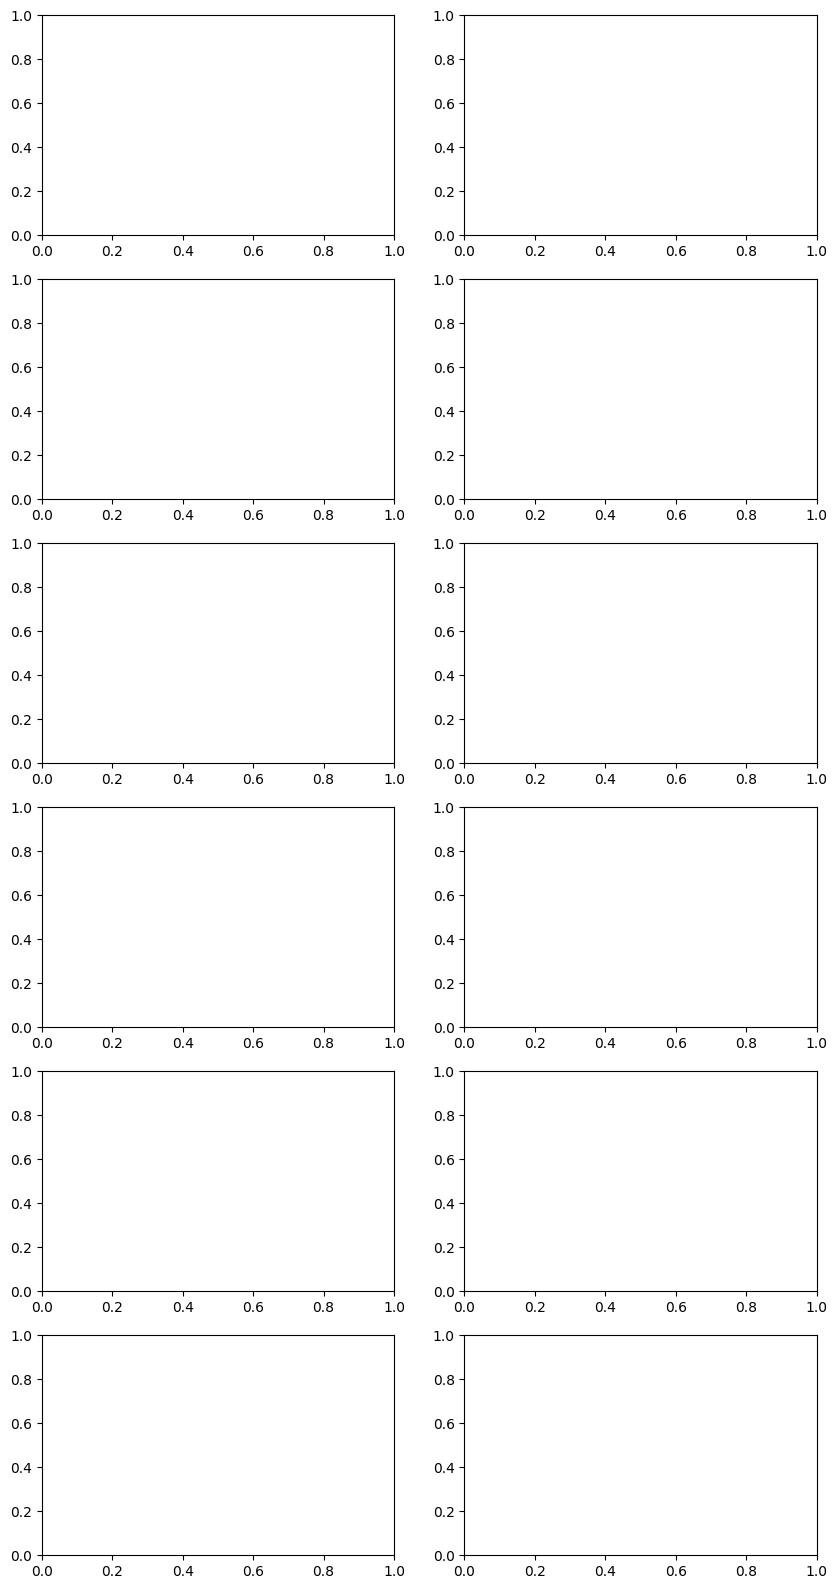

In [18]:
# %matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(6, 2, figsize=(10, 20))
first_frames = dataset[0]["video.ego_view"][0] # first frame
for idx in range(6):
    frame1, frame2 = dataset[idx * 2]["video.ego_view"] # frame: HWC
    # assert that frame1 is the first frame
    assert np.allclose(frame1, first_frames)
    axs[idx, 0].imshow(frame1)
    axs[idx, 1].imshow(frame2)
    axs[idx, 0].axis("off")
    axs[idx, 1].axis("off")
plt.show()